# 06 · Strategy Rotation — StrategyPipelineV1 (Multi-Fitter / Evolver)

Rotates through three fitter × evolver combinations on **P3 sector-filtered pairs**:

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

# ── path setup ────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

# ── project imports ───────────────────────────────────────────────────────
from statarb.context  import AppContext
from statarb.pipeline import StrategyPipelineV1
from statarb.metrics  import get_backtest_metrics, save_strategy_outputs
from statarb.backtest import make_daily_rates
from statarb.fitter   import OLSFitter, VECMFitter
from statarb.evolver  import StaticEvolver, KalmanEvolver

# ── shared context ────────────────────────────────────────────────────────
ctx = AppContext.instance(config_path=str(PROJECT_ROOT / "config.yaml"))
cfg = ctx.cfg

OUTPUT_DIR = Path(cfg["data"]["output_dir"])
TEST_DIR   = Path(cfg["data"]["test_dir"])
PLOT_DIR   = Path(cfg["data"]["plot_dir"])
TEST_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ── strategy definitions ──────────────────────────────────────────────────
STRATEGIES = [
    ("Static_OLS",  OLSFitter,  StaticEvolver),
    ("Static_VECM", VECMFitter, StaticEvolver),
    ("Kalman_OLS",  OLSFitter,  KalmanEvolver),  
    ("Kalman_VECM", VECMFitter, KalmanEvolver),
]

METHODS = ["corr", "dist", "coint", "combined"]

# ── visual style ──────────────────────────────────────────────────────────
STRAT_PALETTES = {
    "Static_OLS":  ["#90CAF9", "#42A5F5", "#1565C0", "#0D47A1"],  
    "Static_VECM": ["#FFCC80", "#FFA726", "#E65100", "#BF360C"],  
    "Kalman_OLS":  ["#CE93D8", "#AB47BC", "#6A1B9A", "#4A148C"],  
    "Kalman_VECM": ["#A5D6A7", "#66BB6A", "#2E7D32", "#1B5E20"],  
}
METHOD_STYLES = {
    "corr":     "-",
    "dist":     "--",
    "coint":    "-.",
    "combined": ":",
}
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False})


## 1 · P3 Pair Counts per Method per Year

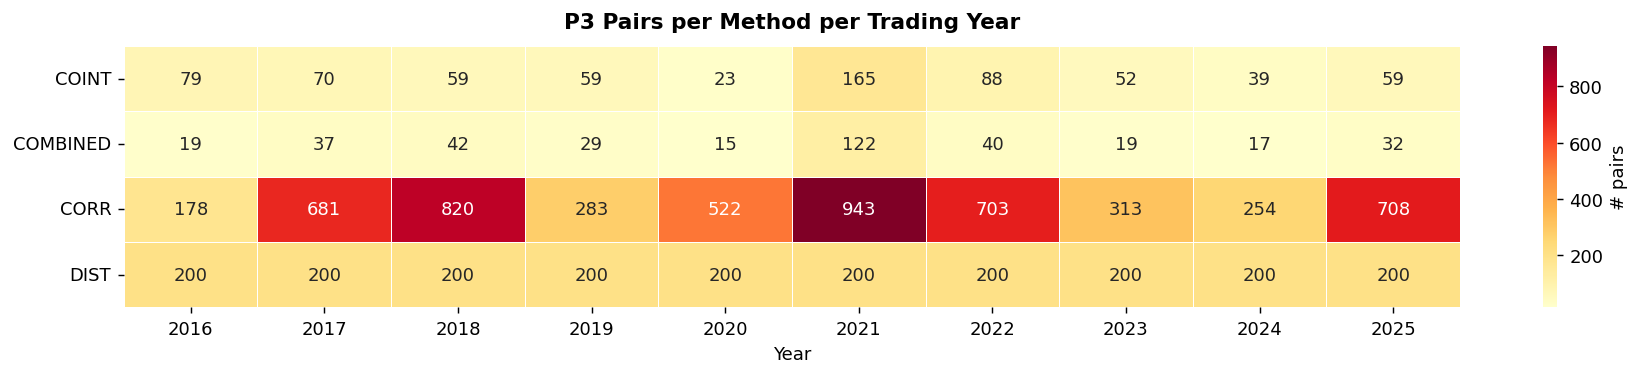

In [2]:
records = []
for method in METHODS:
    for f in sorted(OUTPUT_DIR.glob(f"pairs_P3_{method}_*.parquet")):
        year = int(f.stem.split("_")[-1][:4])
        n    = len(pd.read_parquet(f))
        records.append({"Method": method.upper(), "Year": year, "Pairs": n})

if not records:
    print("WARNING: No pairs_P3_* files found in OUTPUT_DIR."
          " Run notebook 04 first to generate them.")
else:
    df_counts = pd.DataFrame(records)
    pivot = (df_counts.pivot(index="Method", columns="Year", values="Pairs")
             .fillna(0).astype(int))

    fig, ax = plt.subplots(figsize=(14, 3))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd",
                linewidths=0.4, cbar_kws={"label": "# pairs"}, ax=ax)
    ax.set_title("P3 Pairs per Method per Trading Year",
                 fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 2 · Run Strategy Rotation — All Strategies × All Methods

In [3]:
results = {}   # keys: "{strat_label}_{method}"  e.g. "Kalman_VECM_coint"

for strat_label, fitter_cls, evolver_cls in STRATEGIES:
    print(f"\n{'='*80}")
    print(f"  STRATEGY: {strat_label.upper()}")
    print(f"{'='*80}")

    pipeline = StrategyPipelineV1(
        cfg, ctx, strat_label, fitter_cls, evolver_cls,
        file_prefix="pairs_P3",
    )

    for method in METHODS:
        run_key = f"{strat_label}_{method}"

        metrics_path       = TEST_DIR / f"backtest_V1-P3_{strat_label}_metrics_{method}.parquet"
        returns_path       = TEST_DIR / f"backtest_V1-P3_{strat_label}_returns_{method}.parquet"
        pairs_attr_path    = TEST_DIR / f"backtest_V1-P3_{strat_label}_pairs_attr_{method}.parquet"
        pairs_metrics_path = TEST_DIR / f"backtest_V1-P3_{strat_label}_pairs_metrics_{method}.parquet"
        netted_path        = TEST_DIR / f"backtest_V1-P3_{strat_label}_netted_{method}.parquet"

        # ── load cache if all five files exist ────────────────────────────
        if (metrics_path.exists() and returns_path.exists() and
                pairs_attr_path.exists() and pairs_metrics_path.exists() and
                netted_path.exists()):
            df_m      = pd.read_parquet(metrics_path)
            df_r      = pd.read_parquet(returns_path)
            df_pa_ret = pd.read_parquet(pairs_attr_path)
            df_pa_met = pd.read_parquet(pairs_metrics_path)
            df_netted = pd.read_parquet(netted_path)
            df_a_dict = {
                "per_pair_returns": df_pa_ret,
                "per_pair_metrics": df_pa_met,
                "df_netted":        df_netted,
            }
            results[run_key] = (df_m, df_r, df_a_dict)
            print(f"  [{run_key:<28}] loaded from cache")
            continue

        # ── run pipeline ──────────────────────────────────────────────────
        print(f"\n  Running: {strat_label} × {method.upper()}")

        try:
            raw = pipeline.run_method(method)
        except Exception as exc:
            print(f"  [ERROR] {run_key}: {exc}")
            continue

        if len(raw) == 2:
            df_m, df_r = raw
            df_a_dict  = {}
        else:
            df_m, df_r, df_a_dict = raw

        if df_m.empty:
            print(f"  [SKIP] {run_key}: pipeline returned no results — "
                  f"check pairs_P3_{method}_*.parquet exists in OUTPUT_DIR")
            continue

        results[run_key] = (df_m, df_r, df_a_dict)

        save_strategy_outputs(
            backtest_records     = df_m,
            pair_returns         = df_r,
            pair_attributes_dict = df_a_dict,
            metrics_path         = str(metrics_path),
            returns_path         = str(returns_path),
            pairs_attr_path      = str(pairs_attr_path),
            pairs_metrics_path   = str(pairs_metrics_path),
            netted_path          = str(netted_path),
        )
        sharpe_mean = df_m["Sharpe Ratio"].mean() if "Sharpe Ratio" in df_m.columns else float("nan")
        print(f"  [{run_key:<28}] done — {len(df_m)} years | "
              f"Sharpe={sharpe_mean:.3f} | "
              f"Saved → {metrics_path.name}")

print(f"\nAll runs complete. results dict has {len(results)} entries:")
for k in sorted(results):
    df_m, df_r, _ = results[k]
    print(f"  {k:<30} {len(df_m)} years  {df_r.shape[0]} days  "
          f"{df_r.shape[1]} pair-cols")



  STRATEGY: STATIC_OLS
  [Static_OLS_corr             ] loaded from cache
  [Static_OLS_dist             ] loaded from cache
  [Static_OLS_coint            ] loaded from cache
  [Static_OLS_combined         ] loaded from cache

  STRATEGY: STATIC_VECM
  [Static_VECM_corr            ] loaded from cache
  [Static_VECM_dist            ] loaded from cache
  [Static_VECM_coint           ] loaded from cache
  [Static_VECM_combined        ] loaded from cache

  STRATEGY: KALMAN_OLS
  [Kalman_OLS_corr             ] loaded from cache
  [Kalman_OLS_dist             ] loaded from cache
  [Kalman_OLS_coint            ] loaded from cache
  [Kalman_OLS_combined         ] loaded from cache

  STRATEGY: KALMAN_VECM
  [Kalman_VECM_corr            ] loaded from cache
  [Kalman_VECM_dist            ] loaded from cache
  [Kalman_VECM_coint           ] loaded from cache
  [Kalman_VECM_combined        ] loaded from cache

All runs complete. results dict has 16 entries:
  Kalman_OLS_coint               10 y

## 3 · Growth of $1: Strategy × Method

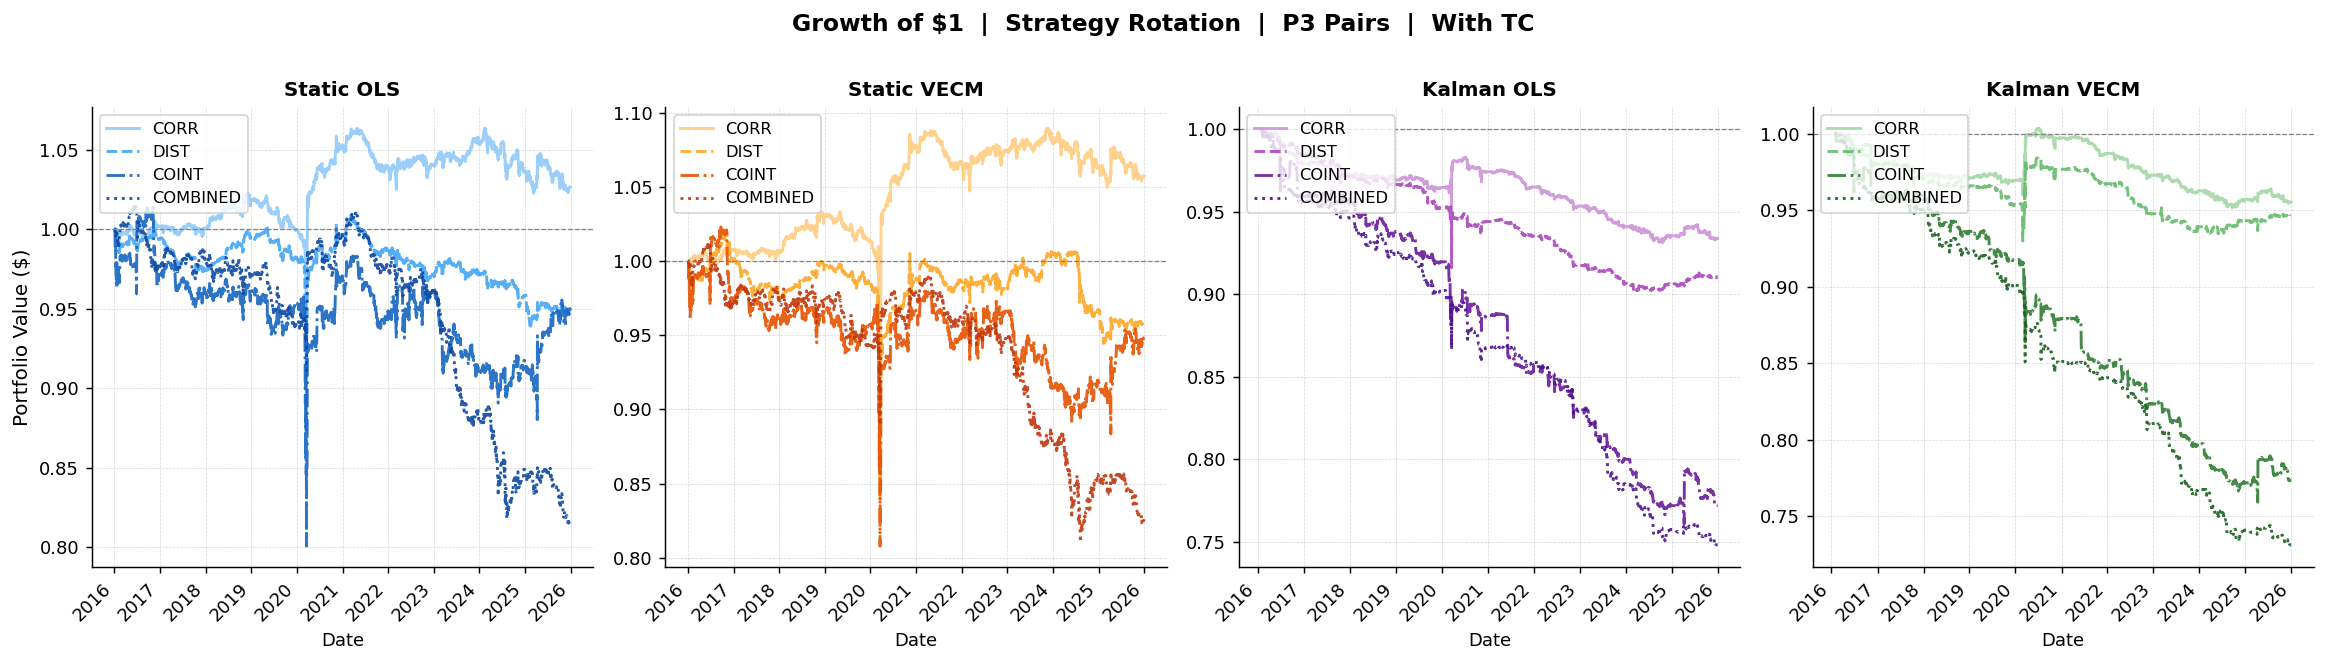

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (strat_label, _, __) in zip(axes, STRATEGIES):
    plotted = False
    for method in METHODS:
        color = STRAT_PALETTES[strat_label][METHODS.index(method)]
        run_key = f"{strat_label}_{method}"
        if run_key not in results:
            continue
        df_m, df_r, _ = results[run_key]
        if df_r.empty:
            continue
        equity = df_r.sum(axis=1).cumsum().apply(np.exp)
        ax.plot(equity.index, equity.values,
                linestyle=METHOD_STYLES[method],
                color=color, linewidth=1.6, alpha=0.9,
                label=method.upper())
        plotted = True

    ax.axhline(1.0, color="grey", linewidth=0.7, linestyle="--")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax.set_title(strat_label.replace("_", " "), fontweight="bold", fontsize=11)
    ax.set_xlabel("Date")
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    if plotted:
        ax.legend(fontsize=9, loc="upper left")

axes[0].set_ylabel("Portfolio Value ($)", fontsize=11)
fig.suptitle("Growth of $1  |  Strategy Rotation  |  P3 Pairs  |  With TC",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 4 · Drawdown Comparison

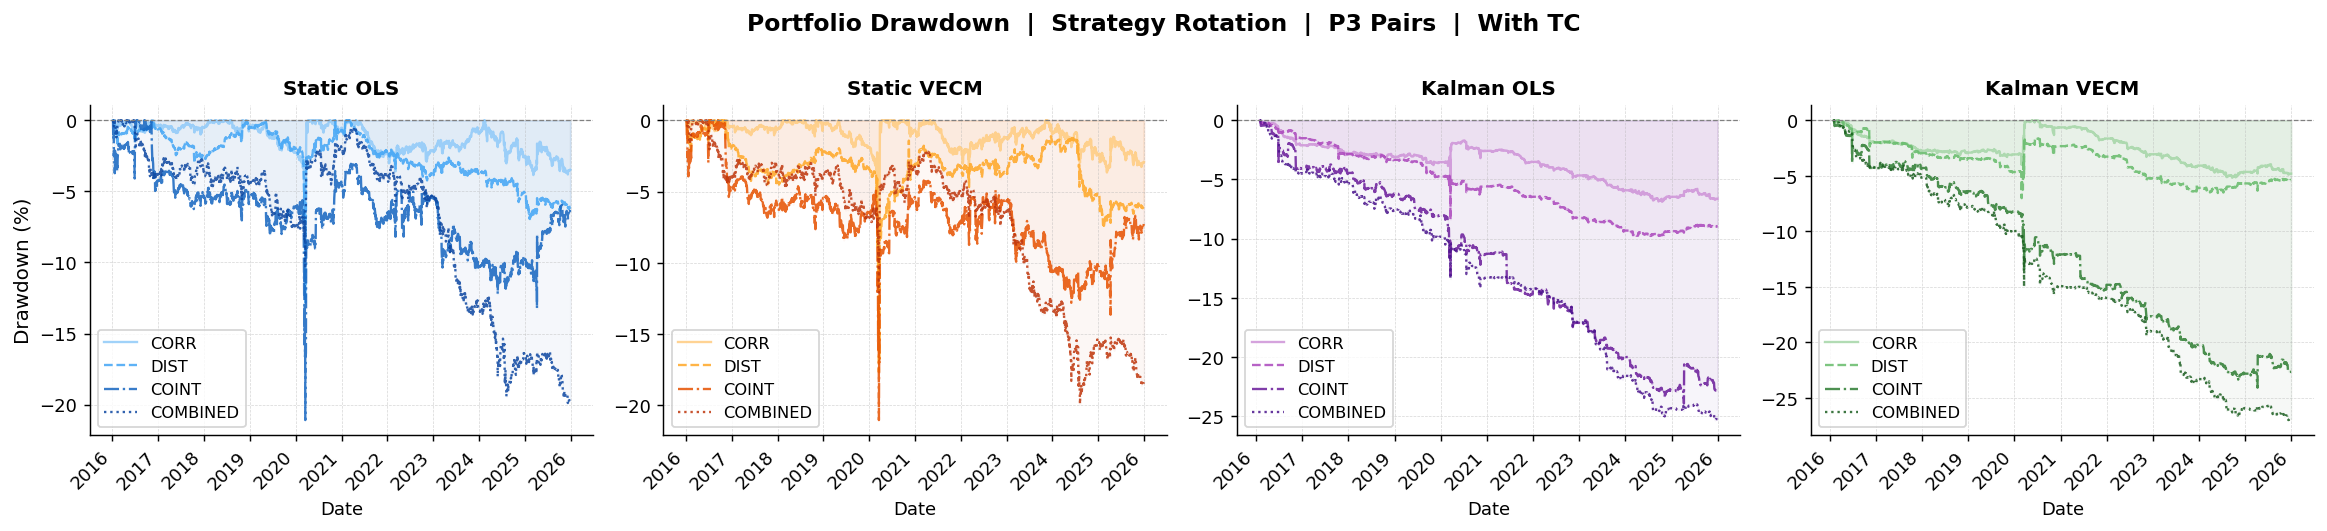

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (strat_label, _, __) in zip(axes, STRATEGIES):
    for method in METHODS:
        color = STRAT_PALETTES[strat_label][METHODS.index(method)]
        run_key = f"{strat_label}_{method}"
        if run_key not in results:
            continue
        _, df_r, _ = results[run_key]
        if df_r.empty:
            continue
        equity = df_r.sum(axis=1).cumsum().apply(np.exp)
        dd     = ((equity / equity.cummax()) - 1) * 100
        ax.plot(dd.index, dd.values,
                linestyle=METHOD_STYLES[method],
                color=color, linewidth=1.3, alpha=0.85,
                label=method.upper())
        ax.fill_between(dd.index, dd.values, 0, alpha=0.04, color=color)

    ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax.set_title(strat_label.replace("_", " "), fontweight="bold", fontsize=11)
    ax.set_xlabel("Date")
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    ax.legend(fontsize=9, loc="lower left")

axes[0].set_ylabel("Drawdown (%)", fontsize=11)
fig.suptitle("Portfolio Drawdown  |  Strategy Rotation  |  P3 Pairs  |  With TC",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 5 · Portfolio-Level Performance Metrics

In [6]:
METRIC_COLS = [
    "Sharpe Ratio", "Annual Excess Return", "Annual Volatility",
    "Maximum Drawdown (MDD)", "Calmar Ratio", "Sortino Ratio",
    "Win Rate", "Longest Drawdown Duration", "Total Trades",
]
FMT = {
    "Sharpe Ratio":              "{:.3f}",
    "Annual Excess Return":      "{:.2%}",
    "Annual Volatility":         "{:.2%}",
    "Maximum Drawdown (MDD)":    "{:.2%}",
    "Calmar Ratio":              "{:.3f}",
    "Sortino Ratio":             "{:.3f}",
    "Win Rate":                  "{:.2%}",
    "Longest Drawdown Duration": "{:.0f} days",
    "Total Trades":              "{:.0f}",
}

summary_rows = []
for strat_label, _, __ in STRATEGIES:
    for method in METHODS:
        run_key = f"{strat_label}_{method}"
        if run_key not in results:
            continue
        df_m, df_r, df_a = results[run_key]
        if df_r.empty:
            continue

        net_ret = df_r.sum(axis=1)
        equity  = net_ret.cumsum().apply(np.exp).rename("EquityCurve").to_frame()
        df_rates = make_daily_rates(cfg, equity.index)
        m = get_backtest_metrics(equity, risk_free_rate=df_rates["rfr"])

        if isinstance(df_a, dict) and "df_netted" in df_a and not df_a["df_netted"].empty:
            chg = df_a["df_netted"].diff().fillna(0)
            m["Total Trades"] = int((chg != 0).sum().sum())
        else:
            m["Total Trades"] = 0

        m["Strategy"] = strat_label
        m["Method"]   = method.upper()
        summary_rows.append(m)

if summary_rows:
    df_summary = (pd.DataFrame(summary_rows)
                  .set_index(["Strategy", "Method"]))
    valid_cols = [c for c in METRIC_COLS if c in df_summary.columns]
    df_summary = df_summary[valid_cols]

    display(
        df_summary.style
        .format({k: v for k, v in FMT.items() if k in df_summary.columns})
        .background_gradient(
            subset=[c for c in ["Sharpe Ratio", "Calmar Ratio", "Sortino Ratio"]
                    if c in df_summary.columns],
            cmap="RdYlGn",
        )
        .set_caption(
            "StrategyV1 Walk-Forward — Full-Period Portfolio Metrics  |  P3 Pairs  |  With TC"
        )
    )
else:
    print("No results in `results` dict yet — run Cell 5 first.")


## 6 · Year-by-Year Sharpe Heatmap

Rows = strategy × method combinations.  Columns = trading years.  
Green = positive Sharpe, Red = negative.

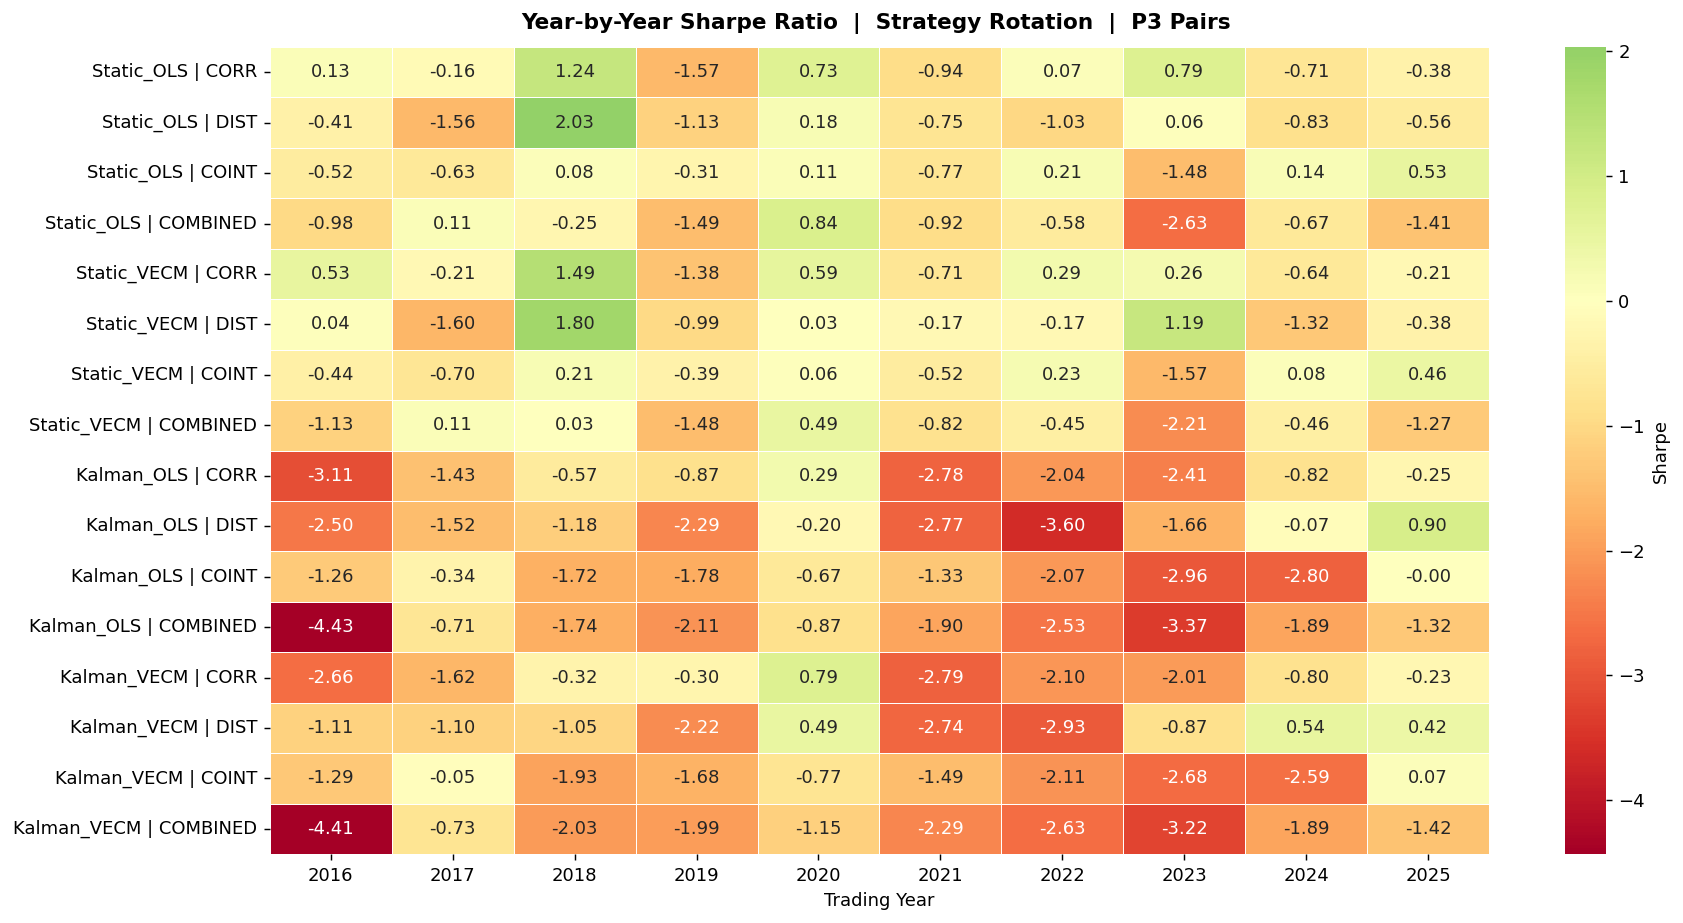

In [7]:
heatmap_rows = {}

for strat_label, _, __ in STRATEGIES:
    for method in METHODS:
        run_key = f"{strat_label}_{method}"
        if run_key not in results:
            continue
        df_m, _, __ = results[run_key]
        if df_m.empty or "Sharpe Ratio" not in df_m.columns:
            continue
        row_label = f"{strat_label} | {method.upper()}"
        heatmap_rows[row_label] = {}
        for year_str in df_m.index:
            s = df_m.loc[year_str, "Sharpe Ratio"]
            heatmap_rows[row_label][int(year_str)] = (
                round(float(s), 2) if np.isfinite(s) else np.nan
            )

df_ys = pd.DataFrame(heatmap_rows).T.sort_index(axis=1)

fig_h = max(4, len(df_ys) * 0.45)
fig, ax = plt.subplots(figsize=(14, fig_h))
sns.heatmap(
    df_ys.astype(float), annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.4,
    cbar_kws={"label": "Sharpe"}, ax=ax
)
ax.set_title(
    "Year-by-Year Sharpe Ratio  |  Strategy Rotation  |  P3 Pairs ",
    fontsize=12, fontweight="bold", pad=10
)
ax.set_xlabel("Trading Year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 7 · Strategy Head-to-Head Comparison

In [8]:
comp_rows = []
for strat_label, _, __ in STRATEGIES:
    sharpes, returns, vols = [], [], []
    total_trades = 0
    for method in METHODS:
        run_key = f"{strat_label}_{method}"
        if run_key not in results:
            continue
        df_m, df_r, df_a = results[run_key]
        if df_r.empty:
            continue
        equity   = df_r.sum(axis=1).cumsum().apply(np.exp).rename("EquityCurve").to_frame()
        df_rates = make_daily_rates(cfg, equity.index)
        m = get_backtest_metrics(equity, risk_free_rate=df_rates["rfr"])
        sharpes.append(m.get("Sharpe Ratio", np.nan))
        returns.append(m.get("Annual Excess Return", np.nan))
        vols.append(m.get("Annual Volatility", np.nan))
        if isinstance(df_a, dict) and "df_netted" in df_a and not df_a["df_netted"].empty:
            chg = df_a["df_netted"].diff().fillna(0)
            total_trades += int((chg != 0).sum().sum())

    if sharpes:
        comp_rows.append({
            "Strategy":       strat_label,
            "Methods run":    len(sharpes),
            "Avg Sharpe":     round(np.nanmean(sharpes), 3),
            "Best Sharpe":    round(np.nanmax(sharpes),  3),
            "Worst Sharpe":   round(np.nanmin(sharpes),  3),
            "Avg Ann Return": np.nanmean(returns),
            "Avg Ann Vol":    np.nanmean(vols),
            "Total Trades":   total_trades,
        })

if comp_rows:
    df_comp = pd.DataFrame(comp_rows).set_index("Strategy")
    display(
        df_comp.style
        .format({
            "Avg Ann Return": "{:.2%}",
            "Avg Ann Vol":    "{:.2%}",
            "Avg Sharpe":     "{:.3f}",
            "Best Sharpe":    "{:.3f}",
            "Worst Sharpe":   "{:.3f}",
            "Total Trades":   "{:.0f}",
        })
        .background_gradient(subset=["Avg Sharpe", "Best Sharpe"], cmap="RdYlGn")
        .set_caption("Strategy Head-to-Head  |  Averaged across all 4 pair-discovery methods")
    )


,Methods run,Avg Sharpe,Best Sharpe,Worst Sharpe,Avg Ann Return,Avg Ann Vol,Total Trades
Strategy,,,,,,,
Static_OLS,4,-0.185,0.094,-0.569,-0.71%,3.85%,123780
Static_VECM,4,-0.134,0.150,-0.513,-0.58%,4.65%,122673
Kalman_OLS,4,-0.936,-0.565,-1.549,-1.93%,1.94%,139125
Kalman_VECM,4,-0.813,-0.312,-1.578,-1.82%,2.06%,137552


## 8 · Top and Bottom Pairs per Strategy

In [9]:
for strat_label, _, __ in STRATEGIES:
    print(f"\n{'='*72}")
    print(f"  {strat_label.upper()}")
    print(f"{'='*72}")

    for method in METHODS:
        run_key = f"{strat_label}_{method}"
        if run_key not in results:
            continue
        df_m, df_r, df_a = results[run_key]
        if df_r.empty:
            continue

        equity       = df_r.sum(axis=1).cumsum().apply(np.exp)
        total_return = equity.iloc[-1] - 1.0
        print(f"  [{method.upper():<8}]  "
              f"{len(df_m)} yrs | "
              f"{df_r.shape[0]} days | "
              f"total return = {total_return:+.2%}")

        ppm = df_a.get("per_pair_metrics", pd.DataFrame()) if isinstance(df_a, dict) else pd.DataFrame()
        if ppm.empty or "Sharpe Ratio" not in ppm.columns:
            print("    no per-pair metrics")
            continue

        df_sorted = ppm.sort_values("Sharpe Ratio", ascending=False)
        print("    ▲ Top 3:")
        for _, row in df_sorted.head(3).iterrows():
            print(f"       {row['ticker1']}-{row['ticker2']:<12}"
                  f" Sharpe={row['Sharpe Ratio']:5.2f}"
                  f" Ret={row.get('Annual Excess Return', float('nan')):+.2%}")
        print("    ▼ Bottom 3:")



  STATIC_OLS
  [CORR    ]  10 yrs | 2513 days | total return = +2.66%
    ▲ Top 3:
       INTC-MU           Sharpe= 2.49 Ret=+40.35%
       COST-PG           Sharpe= 1.96 Ret=+14.43%
       D-PEG          Sharpe= 1.85 Ret=+16.87%
    ▼ Bottom 3:
  [DIST    ]  10 yrs | 2513 days | total return = -5.25%
    ▲ Top 3:
       BDX-MDT          Sharpe= 1.65 Ret=+5.76%
       ACN-INTU         Sharpe= 1.45 Ret=+6.99%
       ADI-TXN          Sharpe= 1.39 Ret=+15.65%
    ▼ Bottom 3:
  [COINT   ]  10 yrs | 2513 days | total return = -4.96%
    ▲ Top 3:
       ELV-ZTS          Sharpe= 1.95 Ret=+25.86%
       AMAT-UBER         Sharpe= 1.58 Ret=+23.06%
       WST-ZBH          Sharpe= 1.57 Ret=+36.89%
    ▼ Bottom 3:
  [COMBINED]  10 yrs | 2513 days | total return = -18.43%
    ▲ Top 3:
       AMAT-UBER         Sharpe= 1.58 Ret=+23.06%
       IQV-LH           Sharpe= 1.16 Ret=+8.76%
       ROK-SWK          Sharpe= 0.74 Ret=+7.04%
    ▼ Bottom 3:

  STATIC_VECM
  [CORR    ]  10 yrs | 2513 days | total